In [14]:
import os
import time
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.models import resnet18


# Paths + device

DATA_ROOT = os.path.expanduser("~/shift_aware_conformal_data")
OUTPUT_ROOT = os.path.expanduser("~/shift_aware_conformal_outputs")

os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(OUTPUT_ROOT, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DATA_ROOT  :", DATA_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("Device     :", device)


BATCH_SIZE = 128
NUM_WORKERS = 0
TRAIN_SIZE = 45000
CAL_SIZE = 5000
EPOCHS = 20
SEED = 42


def get_cifar10_loaders(
    root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    train_size=TRAIN_SIZE,
    cal_size=CAL_SIZE,
    seed=SEED
):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616)
        ),
    ])

    transform_eval = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616)
        ),
    ])

    full_train_aug = datasets.CIFAR10(
        root=root,
        train=True,
        download=True,
        transform=transform_train
    )

    full_train_plain = datasets.CIFAR10(
        root=root,
        train=True,
        download=False,
        transform=transform_eval
    )

    test_dataset = datasets.CIFAR10(
        root=root,
        train=False,
        download=True,
        transform=transform_eval
    )

    assert train_size + cal_size <= len(full_train_aug), "train_size + cal_size must be <= 50000"

    generator = torch.Generator().manual_seed(seed)

    selected_indices = torch.randperm(len(full_train_aug), generator=generator)[:train_size + cal_size].tolist()
    train_indices = selected_indices[:train_size]
    cal_indices = selected_indices[train_size:train_size + cal_size]

    train_dataset = torch.utils.data.Subset(full_train_aug, train_indices)
    cal_dataset = torch.utils.data.Subset(full_train_plain, cal_indices)

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_mem
    )

    cal_loader = DataLoader(
        cal_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_mem
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_mem
    )

    return train_loader, cal_loader, test_loader


# Model

class ResNet18CIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.backbone.maxpool = nn.Identity()
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def forward_with_features(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        x = self.backbone.avgpool(x)
        features = torch.flatten(x, 1)
        logits = self.backbone.fc(features)
        return logits, features


# Eval function

def evaluate(model, loader, criterion, device):
    model.eval()
    total = 0
    correct = 0
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item() * labels.size(0)

    return running_loss / total, correct / total


# Load data

train_loader, cal_loader, test_loader = get_cifar10_loaders()
print("Train batches:", len(train_loader))
print("Cal batches  :", len(cal_loader))
print("Test batches :", len(test_loader))


model = ResNet18CIFAR(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_test_acc = 0.0
history = {
    "train_loss": [],
    "train_acc": [],
    "cal_acc": [],
    "test_acc": [],
}

best_model_path = os.path.join(OUTPUT_ROOT, "resnet18_cifar10_best_debug.pt")
history_path = os.path.join(OUTPUT_ROOT, "train_history_debug.npz")


start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    total = 0
    correct = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{running_loss/total:.4f}",
            "acc": f"{correct/total:.4f}"
        })

    scheduler.step()

    train_loss = running_loss / total
    train_acc = correct / total
    _, cal_acc = evaluate(model, cal_loader, criterion, device)
    _, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["cal_acc"].append(cal_acc)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss={train_loss:.4f}, "
        f"Train Acc={train_acc:.4f}, "
        f"Cal Acc={cal_acc:.4f}, "
        f"Test Acc={test_acc:.4f}"
    )

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved best model to: {best_model_path}")

elapsed = time.time() - start_time


np.savez_compressed(
    history_path,
    train_loss=np.array(history["train_loss"]),
    train_acc=np.array(history["train_acc"]),
    cal_acc=np.array(history["cal_acc"]),
    test_acc=np.array(history["test_acc"]),
)

print("\nTraining complete.")
print(f"Best test accuracy: {best_test_acc:.4f}")
print(f"Total time: {elapsed/60:.2f} minutes")
print("History saved to:", history_path)
print("Best model saved to:", best_model_path)

DATA_ROOT  : /Users/arifhossen/shift_aware_conformal_data
OUTPUT_ROOT: /Users/arifhossen/shift_aware_conformal_outputs
Device     : cpu
Train batches: 352
Cal batches  : 40
Test batches : 79


Epoch 1/20: 100%|████| 352/352 [12:09<00:00,  2.07s/it, loss=2.0944, acc=0.2546]


Epoch 1: Train Loss=2.0944, Train Acc=0.2546, Cal Acc=0.3398, Test Acc=0.3441
Saved best model to: /Users/arifhossen/shift_aware_conformal_outputs/resnet18_cifar10_best_debug.pt


Epoch 2/20: 100%|████| 352/352 [11:02<00:00,  1.88s/it, loss=1.4993, acc=0.4459]


Epoch 2: Train Loss=1.4993, Train Acc=0.4459, Cal Acc=0.5068, Test Acc=0.5102
Saved best model to: /Users/arifhossen/shift_aware_conformal_outputs/resnet18_cifar10_best_debug.pt


...

Epoch 18: Train Loss=0.1241, Train Acc=0.9585, Cal Acc=0.9120, Test Acc=0.9066
Saved best model to: /Users/arifhossen/shift_aware_conformal_outputs/resnet18_cifar10_best_debug.pt


Epoch 19/20: 100%|███| 352/352 [10:18<00:00,  1.76s/it, loss=0.1017, acc=0.9672]


Epoch 19: Train Loss=0.1017, Train Acc=0.9672, Cal Acc=0.9120, Test Acc=0.9103
Saved best model to: /Users/arifhossen/shift_aware_conformal_outputs/resnet18_cifar10_best_debug.pt


Epoch 20/20: 100%|███| 352/352 [10:07<00:00,  1.73s/it, loss=0.0895, acc=0.9721]


Epoch 20: Train Loss=0.0895, Train Acc=0.9721, Cal Acc=0.9158, Test Acc=0.9130
Saved best model to: /Users/arifhossen/shift_aware_conformal_outputs/resnet18_cifar10_best_debug.pt

Training complete.
Best test accuracy: 0.9130
Total time: 244.95 minutes
History saved to: /Users/arifhossen/shift_aware_conformal_outputs/train_history_debug.npz
Best model saved to: /Users/arifhossen/shift_aware_conformal_outputs/resnet18_cifar10_best_debug.pt


In [16]:
import os
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet18


# Paths + device

DATA_ROOT = os.path.expanduser("~/shift_aware_conformal_data")
OUTPUT_ROOT = os.path.expanduser("~/shift_aware_conformal_outputs")

os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(OUTPUT_ROOT, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DATA_ROOT  :", DATA_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("Device     :", device)


BATCH_SIZE = 128
NUM_WORKERS = 0
TRAIN_SIZE = 45000
CAL_SIZE = 5000
SEED = 42

MODEL_PATH = os.path.join(OUTPUT_ROOT, "resnet18_cifar10_best_debug.pt")
CAL_SAVE_PATH = os.path.join(OUTPUT_ROOT, "cal_outputs_full.npz")
TEST_SAVE_PATH = os.path.join(OUTPUT_ROOT, "test_outputs_full.npz")

print("MODEL_PATH    :", MODEL_PATH)
print("CAL_SAVE_PATH :", CAL_SAVE_PATH)
print("TEST_SAVE_PATH:", TEST_SAVE_PATH)


def get_cifar10_loaders(
    root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    train_size=TRAIN_SIZE,
    cal_size=CAL_SIZE,
    seed=SEED
):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616)
        ),
    ])

    transform_eval = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616)
        ),
    ])

    full_train_aug = datasets.CIFAR10(
        root=root,
        train=True,
        download=True,
        transform=transform_train
    )

    full_train_plain = datasets.CIFAR10(
        root=root,
        train=True,
        download=False,
        transform=transform_eval
    )

    test_dataset = datasets.CIFAR10(
        root=root,
        train=False,
        download=True,
        transform=transform_eval
    )

    assert train_size + cal_size <= len(full_train_aug), "train_size + cal_size must be <= 50000"

    generator = torch.Generator().manual_seed(seed)
    selected_indices = torch.randperm(len(full_train_aug), generator=generator)[:train_size + cal_size].tolist()

    train_indices = selected_indices[:train_size]
    cal_indices = selected_indices[train_size:train_size + cal_size]

    train_dataset = torch.utils.data.Subset(full_train_aug, train_indices)
    cal_dataset = torch.utils.data.Subset(full_train_plain, cal_indices)

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_mem
    )

    cal_loader = DataLoader(
        cal_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_mem
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_mem
    )

    return train_loader, cal_loader, test_loader


class ResNet18CIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.backbone.maxpool = nn.Identity()
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def forward_with_features(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        x = self.backbone.avgpool(x)
        features = torch.flatten(x, 1)
        logits = self.backbone.fc(features)
        return logits, features


def collect_outputs(model, loader, device):
    model.eval()

    all_logits = []
    all_probs = []
    all_labels = []
    all_features = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Inference"):
            images = images.to(device)
            labels = labels.to(device)

            logits, features = model.forward_with_features(images)
            probs = torch.softmax(logits, dim=1)

            all_logits.append(logits.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_features.append(features.cpu().numpy())

    outputs = {
        "logits": np.concatenate(all_logits, axis=0),
        "probs": np.concatenate(all_probs, axis=0),
        "labels": np.concatenate(all_labels, axis=0),
        "features": np.concatenate(all_features, axis=0),
    }
    return outputs

def save_npz(path, data_dict):
    np.savez_compressed(
        path,
        logits=data_dict["logits"],
        probs=data_dict["probs"],
        labels=data_dict["labels"],
        features=data_dict["features"]
    )


# Load model

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model checkpoint not found: {MODEL_PATH}\n"
        f"Make sure Notebook 1 saved the full model with this exact filename."
    )

model = ResNet18CIFAR(num_classes=10).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("Loaded model successfully.")


_, cal_loader, test_loader = get_cifar10_loaders()
print("Cal batches :", len(cal_loader))
print("Test batches:", len(test_loader))


print("\nRunning calibration inference...")
cal_outputs = collect_outputs(model, cal_loader, device)
save_npz(CAL_SAVE_PATH, cal_outputs)

print("Saved calibration outputs.")
for k, v in cal_outputs.items():
    print(f"cal_{k}: {v.shape}")


print("\nRunning test inference...")
test_outputs = collect_outputs(model, test_loader, device)
save_npz(TEST_SAVE_PATH, test_outputs)

print("Saved test outputs.")
for k, v in test_outputs.items():
    print(f"test_{k}: {v.shape}")

print("\nDone.")
print("Calibration file:", CAL_SAVE_PATH)
print("Test file       :", TEST_SAVE_PATH)

DATA_ROOT  : /Users/arifhossen/shift_aware_conformal_data
OUTPUT_ROOT: /Users/arifhossen/shift_aware_conformal_outputs
Device     : cpu
MODEL_PATH    : /Users/arifhossen/shift_aware_conformal_outputs/resnet18_cifar10_best_debug.pt
CAL_SAVE_PATH : /Users/arifhossen/shift_aware_conformal_outputs/cal_outputs_full.npz
TEST_SAVE_PATH: /Users/arifhossen/shift_aware_conformal_outputs/test_outputs_full.npz
Loaded model successfully.
Cal batches : 40
Test batches: 79

Running calibration inference...


Inference: 100%|████████████████████████████████| 40/40 [00:19<00:00,  2.01it/s]


Saved calibration outputs.
cal_logits: (5000, 10)
cal_probs: (5000, 10)
cal_labels: (5000,)
cal_features: (5000, 512)

Running test inference...


Inference: 100%|████████████████████████████████| 79/79 [00:41<00:00,  1.89it/s]


Saved test outputs.
test_logits: (10000, 10)
test_probs: (10000, 10)
test_labels: (10000,)
test_features: (10000, 512)

Done.
Calibration file: /Users/arifhossen/shift_aware_conformal_outputs/cal_outputs_full.npz
Test file       : /Users/arifhossen/shift_aware_conformal_outputs/test_outputs_full.npz


In [19]:
import os

root = os.path.expanduser("~/shift_aware_conformal_data/CIFAR-10-C")
print("Exists:", os.path.exists(root))
if os.path.exists(root):
    print(os.listdir(root)[:10])

Exists: False


In [3]:
import os
import numpy as np



PROJECT_ROOT = os.getcwd()   # since notebook is inside shift_aware_conformal
OUTPUT_ROOT = os.path.join(PROJECT_ROOT, "shift_aware_conformal_outputs")

CAL_PATH = os.path.join(OUTPUT_ROOT, "cal_outputs_full.npz")
TEST_PATH = os.path.join(OUTPUT_ROOT, "test_outputs_full.npz")
RESULTS_PATH = os.path.join(OUTPUT_ROOT, "aps_raps_results_full.npz")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("OUTPUT_ROOT  :", OUTPUT_ROOT)
print("CAL_PATH     :", CAL_PATH)
print("TEST_PATH    :", TEST_PATH)
print("RESULTS_PATH :", RESULTS_PATH)
print("CAL exists?  :", os.path.exists(CAL_PATH))
print("TEST exists? :", os.path.exists(TEST_PATH))

if not os.path.exists(CAL_PATH):
    raise FileNotFoundError(f"Calibration file not found: {CAL_PATH}")

if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(f"Test file not found: {TEST_PATH}")


cal_data = np.load(CAL_PATH)
test_data = np.load(TEST_PATH)

cal_probs = cal_data["probs"]
cal_labels = cal_data["labels"]

test_probs = test_data["probs"]
test_labels = test_data["labels"]

print("\nLoaded arrays:")
print("cal_probs   :", cal_probs.shape)
print("cal_labels  :", cal_labels.shape)
print("test_probs  :", test_probs.shape)
print("test_labels :", test_labels.shape)


# Generalized APS / RAPS functions
# APS-rand = lambda_reg = 0
# RAPS     = lambda_reg > 0


def conformal_quantile(scores, alpha):
    """
    Finite-sample split conformal quantile:
    k = ceil((n+1)(1-alpha)) - 1  with 0-based indexing
    """
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha))) - 1
    k = min(max(k, 0), n - 1)
    return np.sort(scores)[k]


def compute_raps_score(prob_vec, true_label, lambda_reg=0.0, k_reg=0, randomized=True, rng=None):
    """
    General conformity score.

    APS-rand is the special case lambda_reg = 0.
    Deterministic APS is randomized=False and lambda_reg=0.

    Score:
        E_i = sum_{j <= L_i} s_j + lambda_reg * max(L_i - k_reg, 0)
              - U * s_{L_i}        (if randomized=True)

    where L_i is the 1-based rank of the true label in descending probability order.
    """
    if rng is None:
        rng = np.random.default_rng()

    sorted_idx = np.argsort(-prob_vec)
    sorted_probs = prob_vec[sorted_idx]

    # 1-based rank of the true label
    L = int(np.where(sorted_idx == true_label)[0][0]) + 1

    score = np.sum(sorted_probs[:L]) + lambda_reg * max(L - k_reg, 0)

    if randomized:
        u = rng.uniform()
        score -= u * sorted_probs[L - 1]

    return float(score)


def compute_all_raps_scores(probs, labels, lambda_reg=0.0, k_reg=0, randomized=True, seed=0):
    rng = np.random.default_rng(seed)
    scores = []
    for i in range(len(labels)):
        s = compute_raps_score(
            probs[i],
            labels[i],
            lambda_reg=lambda_reg,
            k_reg=k_reg,
            randomized=randomized,
            rng=rng
        )
        scores.append(s)
    return np.array(scores, dtype=np.float64)


def build_raps_set(prob_vec, qhat, lambda_reg=0.0, k_reg=0, randomized=True, rng=None):
    """
    Build APS/RAPS prediction set.

    For each rank j, define penalized cumulative score:
        cum_j = sum_{i <= j} s_i + lambda_reg * max(j - k_reg, 0)

    Deterministic version:
        include top labels until cum_j > qhat, return top-L

    Randomized version:
        randomize the boundary label to avoid conservative over-coverage.
    """
    if rng is None:
        rng = np.random.default_rng()

    sorted_idx = np.argsort(-prob_vec)
    sorted_probs = prob_vec[sorted_idx]
    K = len(sorted_probs)

    penalized_cum = np.array([
        np.sum(sorted_probs[:j]) + lambda_reg * max(j - k_reg, 0)
        for j in range(1, K + 1)
    ], dtype=np.float64)

    count_leq = int(np.sum(penalized_cum <= qhat))

    # If everything is under threshold, return all classes
    if count_leq >= K:
        return [int(x) for x in sorted_idx]

    # Otherwise boundary is at L = count_leq + 1
    L = count_leq + 1

    if randomized:
        boundary_value = penalized_cum[L - 1]
        increment = sorted_probs[L - 1] + (lambda_reg if L > k_reg else 0.0)

        # drop boundary class with this probability
        drop_prob = (boundary_value - qhat) / max(increment, 1e-12)
        drop_prob = float(np.clip(drop_prob, 0.0, 1.0))

        u = rng.uniform()
        if u <= drop_prob:
            L -= 1

    return [int(x) for x in sorted_idx[:L]]


def build_all_prediction_sets(probs, qhat, lambda_reg=0.0, k_reg=0, randomized=True, seed=0):
    rng = np.random.default_rng(seed)
    pred_sets = []
    for prob_vec in probs:
        pred_sets.append(
            build_raps_set(
                prob_vec,
                qhat=qhat,
                lambda_reg=lambda_reg,
                k_reg=k_reg,
                randomized=randomized,
                rng=rng
            )
        )
    return pred_sets


def empirical_coverage(pred_sets, labels):
    covered = 0
    for s, y in zip(pred_sets, labels):
        if int(y) in s:
            covered += 1
    return covered / len(labels)


def average_set_size(pred_sets):
    return float(np.mean([len(s) for s in pred_sets]))


def evaluate_method(alpha, method_name, lambda_reg=0.0, k_reg=0, randomized=True, seed=0):
    cal_scores = compute_all_raps_scores(
        cal_probs,
        cal_labels,
        lambda_reg=lambda_reg,
        k_reg=k_reg,
        randomized=randomized,
        seed=seed
    )
    qhat = conformal_quantile(cal_scores, alpha)

    test_pred_sets = build_all_prediction_sets(
        test_probs,
        qhat=qhat,
        lambda_reg=lambda_reg,
        k_reg=k_reg,
        randomized=randomized,
        seed=seed + 123
    )

    coverage = empirical_coverage(test_pred_sets, test_labels)
    avg_size = average_set_size(test_pred_sets)

    print("\n" + "=" * 70)
    print(f"Method            : {method_name}")
    print(f"Alpha             : {alpha}")
    print(f"Target coverage   : {1 - alpha:.4f}")
    print(f"lambda_reg        : {lambda_reg}")
    print(f"k_reg             : {k_reg}")
    print(f"Randomized        : {randomized}")
    print(f"qhat              : {qhat:.6f}")
    print(f"Empirical coverage: {coverage:.4f}")
    print(f"Coverage gap      : {coverage - (1 - alpha):.4f}")
    print(f"Average set size  : {avg_size:.4f}")

    return {
        "method": method_name,
        "alpha": alpha,
        "target_coverage": 1 - alpha,
        "lambda_reg": lambda_reg,
        "k_reg": k_reg,
        "randomized": randomized,
        "qhat": qhat,
        "empirical_coverage": coverage,
        "coverage_gap": coverage - (1 - alpha),
        "avg_set_size": avg_size,
    }



# Comparing:
# 1) Your old deterministic APS
# 2) Proper randomized APS
# 3) RAPS (actual efficiency fix)


alpha_list = [0.10, 0.05]
all_results = []

# A) old deterministic APS
for alpha in alpha_list:
    all_results.append(
        evaluate_method(
            alpha=alpha,
            method_name="APS-deterministic",
            lambda_reg=0.0,
            k_reg=0,
            randomized=False,
            seed=42
        )
    )

# B) proper randomized APS
for alpha in alpha_list:
    all_results.append(
        evaluate_method(
            alpha=alpha,
            method_name="APS-randomized",
            lambda_reg=0.0,
            k_reg=0,
            randomized=True,
            seed=42
        )
    )

# C) RAPS
# Start with a small regularization; then tune later
for alpha in alpha_list:
    all_results.append(
        evaluate_method(
            alpha=alpha,
            method_name="RAPS",
            lambda_reg=0.01,
            k_reg=2,
            randomized=True,
            seed=42
        )
    )


raps_alpha_90 = [r for r in all_results if r["method"] == "RAPS" and abs(r["alpha"] - 0.10) < 1e-12][0]
qhat_raps_90 = raps_alpha_90["qhat"]

print("\nExample RAPS prediction sets at alpha = 0.10")
rng = np.random.default_rng(999)
for i in range(5):
    pred_set = build_raps_set(
        test_probs[i],
        qhat=qhat_raps_90,
        lambda_reg=0.01,
        k_reg=2,
        randomized=True,
        rng=rng
    )
    print(f"Example {i}: true label = {int(test_labels[i])}, prediction set = {pred_set}")


np.savez_compressed(
    RESULTS_PATH,
    results=np.array(all_results, dtype=object)
)

print("\nSaved APS/RAPS results to:", RESULTS_PATH)

PROJECT_ROOT : /Users/arifhossen/Documents/shift_aware_conformal
OUTPUT_ROOT  : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs
CAL_PATH     : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/cal_outputs_full.npz
TEST_PATH    : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/test_outputs_full.npz
RESULTS_PATH : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/aps_raps_results_full.npz
CAL exists?  : True
TEST exists? : True

Loaded arrays:
cal_probs   : (5000, 10)
cal_labels  : (5000,)
test_probs  : (10000, 10)
test_labels : (10000,)

Method            : APS-deterministic
Alpha             : 0.1
Target coverage   : 0.9000
lambda_reg        : 0.0
k_reg             : 0
Randomized        : False
qhat              : 0.999989
Empirical coverage: 1.0000
Coverage gap      : 0.1000
Average set size  : 5.9427

Method            : APS-deterministic
Alpha             : 0.0

In [ ]:
# step 2. aps system on shifted data

PROJECT_ROOT = /Users/arifhossen/Documents/shift_aware_conformal
DATA_ROOT    = /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_data
OUTPUT_ROOT  = /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs
CAL_PATH     = /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/cal_outputs_full.npz
MODEL_PATH   = /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/resnet18_cifar10_best_debug.pt
Device        : cpu

Loaded clean calibration arrays:
cal_probs shape : (5000, 10)
cal_labels shape: (5000,)
alpha=0.10 -> qhat=0.921488
alpha=0.05 -> qhat=0.968734

Loaded model successfully.

Corruption: gaussian_noise


severity=1 | alpha=0.10 | coverage=0.8155 | gap=-0.0845 | avg_size=1.4443
severity=1 | alpha=0.05 | coverage=0.8802 | gap=-0.0698 | avg_size=1.7486


severity=2 | alpha=0.10 | coverage=0.6853 | gap=-0.2147 | avg_size=1.6394
severity=2 | alpha=0.05 | coverage=0.7611 | gap=-0.1889 | avg_size=2.0387


severity=3 | alpha=0.10 | coverage=0.5262 | gap=-0.3738 | avg_size=1.7049
severity=3 | alpha=0.05 | coverage=0.6051 | gap=-0.3449 | avg_size=2.1342


severity=4 | alpha=0.10 | coverage=0.4503 | gap=-0.4497 | avg_size=1.6810
severity=4 | alpha=0.05 | coverage=0.5318 | gap=-0.4182 | avg_size=2.0992


...

severity=1 | alpha=0.10 | coverage=0.8632 | gap=-0.0368 | avg_size=1.2879
severity=1 | alpha=0.05 | coverage=0.9206 | gap=-0.0294 | avg_size=1.5251


severity=2 | alpha=0.10 | coverage=0.8498 | gap=-0.0502 | avg_size=1.3924
severity=2 | alpha=0.05 | coverage=0.9094 | gap=-0.0406 | avg_size=1.6835


severity=3 | alpha=0.10 | coverage=0.8399 | gap=-0.0601 | avg_size=1.4367
severity=3 | alpha=0.05 | coverage=0.9023 | gap=-0.0477 | avg_size=1.7438


severity=4 | alpha=0.10 | coverage=0.8317 | gap=-0.0683 | avg_size=1.4812
severity=4 | alpha=0.05 | coverage=0.8899 | gap=-0.0601 | avg_size=1.8035


severity=5 | alpha=0.10 | coverage=0.8152 | gap=-0.0848 | avg_size=1.5481
severity=5 | alpha=0.05 | coverage=0.8792 | gap=-0.0708 | avg_size=1.8957

Saved CSV results to: /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step2_cifar10c_results_raps.csv
Saved NPZ results to: /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step2_cifar10c_results_raps.npz


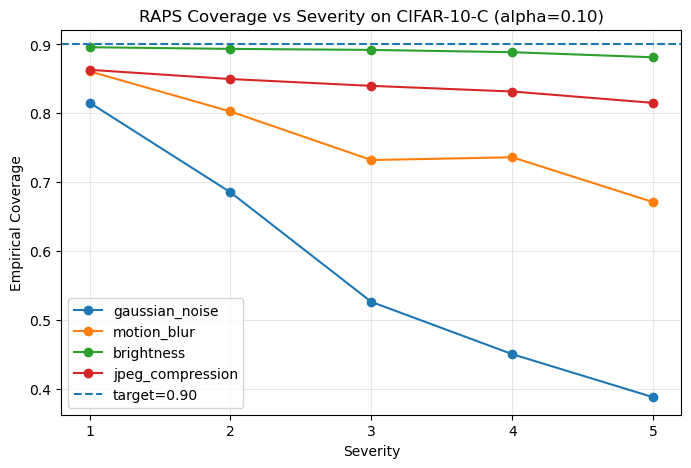

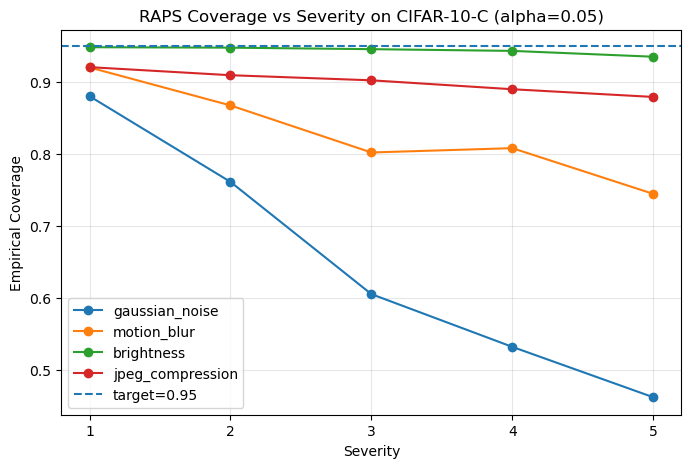

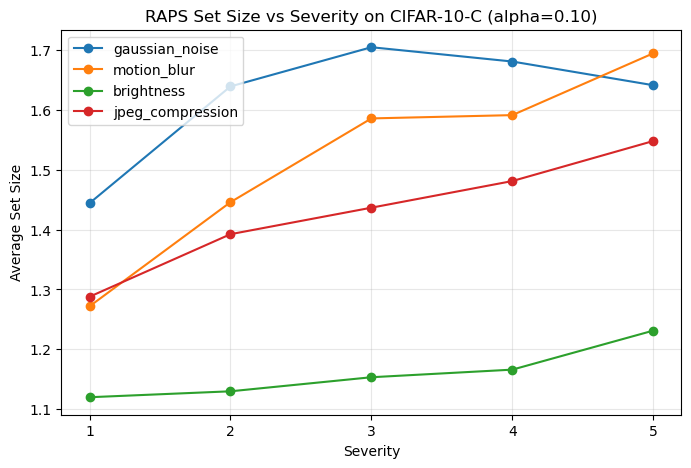

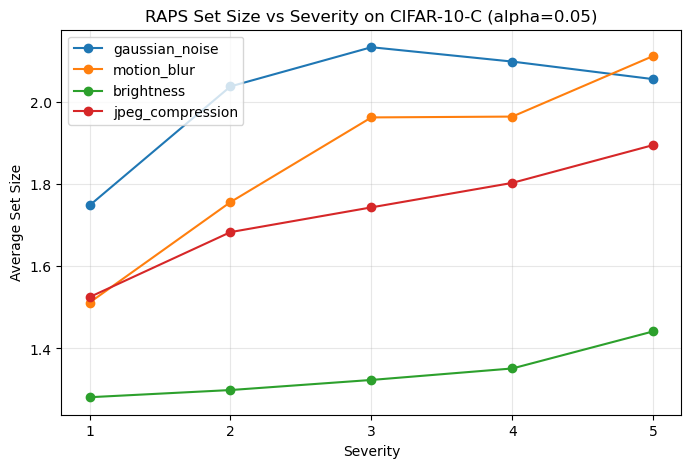


STEP 2 SUMMARY

Alpha = 0.10
------------------------------------------------------------
gaussian_noise       | worst coverage = 0.3878 | max set size = 1.7049
motion_blur          | worst coverage = 0.6711 | max set size = 1.6947
brightness           | worst coverage = 0.8814 | max set size = 1.2312
jpeg_compression     | worst coverage = 0.8152 | max set size = 1.5481

Alpha = 0.05
------------------------------------------------------------
gaussian_noise       | worst coverage = 0.4618 | max set size = 2.1342
motion_blur          | worst coverage = 0.7445 | max set size = 2.1128
brightness           | worst coverage = 0.9351 | max set size = 1.4415
jpeg_compression     | worst coverage = 0.8792 | max set size = 1.8957

Step 2 finished.
Saved files:
 - /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step2_cifar10c_results_raps.csv
 - /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step2_cifar10c_results_raps.npz


In [4]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18


# Paths

PROJECT_ROOT = os.getcwd()
DATA_ROOT = os.path.join(PROJECT_ROOT, "shift_aware_conformal_data")
OUTPUT_ROOT = os.path.join(PROJECT_ROOT, "shift_aware_conformal_outputs")

CIFAR10C_ROOT = os.path.join(DATA_ROOT, "CIFAR-10-C")

CAL_PATH = os.path.join(OUTPUT_ROOT, "cal_outputs_full.npz")
MODEL_PATH = os.path.join(OUTPUT_ROOT, "resnet18_cifar10_best_debug.pt")

# save to new names so you don't overwrite old deterministic results
RESULTS_CSV = os.path.join(OUTPUT_ROOT, "step2_cifar10c_results_raps.csv")
RESULTS_NPZ = os.path.join(OUTPUT_ROOT, "step2_cifar10c_results_raps.npz")

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("OUTPUT_ROOT  =", OUTPUT_ROOT)
print("CAL_PATH     =", CAL_PATH)
print("MODEL_PATH   =", MODEL_PATH)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device        :", device)


if not os.path.exists(CAL_PATH):
    raise FileNotFoundError(f"Missing calibration outputs: {CAL_PATH}")

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Missing trained model: {MODEL_PATH}")

if not os.path.exists(CIFAR10C_ROOT):
    raise FileNotFoundError(
        f"Missing CIFAR-10-C folder: {CIFAR10C_ROOT}\n"
        f"Put the extracted CIFAR-10-C folder there or change CIFAR10C_ROOT."
    )


BATCH_SIZE = 128
NUM_WORKERS = 0
ALPHAS = [0.10, 0.05]

CORRUPTIONS = [
    "gaussian_noise",
    "motion_blur",
    "brightness",
    "jpeg_compression",
]

SEVERITIES = [1, 2, 3, 4, 5]

# Choose method here:
# 1) randomized APS  -> lambda_reg = 0.0, k_reg = 0
# 2) RAPS            -> lambda_reg > 0.0, k_reg > 0
METHOD_NAME = "RAPS"
LAMBDA_REG = 0.01
K_REG = 2
RANDOMIZED = True
SEED = 42


# Randomized APS / RAPS functions

def conformal_quantile(scores, alpha):
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha))) - 1
    k = min(max(k, 0), n - 1)
    return np.sort(scores)[k]


def compute_raps_score(prob_vec, true_label, lambda_reg=0.0, k_reg=0, randomized=True, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    sorted_idx = np.argsort(-prob_vec)
    sorted_probs = prob_vec[sorted_idx]

    # 1-based rank of true label
    L = int(np.where(sorted_idx == true_label)[0][0]) + 1

    score = np.sum(sorted_probs[:L]) + lambda_reg * max(L - k_reg, 0)

    if randomized:
        u = rng.uniform()
        score -= u * sorted_probs[L - 1]

    return float(score)


def compute_all_raps_scores(probs, labels, lambda_reg=0.0, k_reg=0, randomized=True, seed=0):
    rng = np.random.default_rng(seed)
    scores = []
    for i in range(len(labels)):
        scores.append(
            compute_raps_score(
                probs[i],
                labels[i],
                lambda_reg=lambda_reg,
                k_reg=k_reg,
                randomized=randomized,
                rng=rng
            )
        )
    return np.array(scores, dtype=np.float64)


def build_raps_set(prob_vec, qhat, lambda_reg=0.0, k_reg=0, randomized=True, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    sorted_idx = np.argsort(-prob_vec)
    sorted_probs = prob_vec[sorted_idx]
    K = len(sorted_probs)

    penalized_cum = np.array([
        np.sum(sorted_probs[:j]) + lambda_reg * max(j - k_reg, 0)
        for j in range(1, K + 1)
    ], dtype=np.float64)

    count_leq = int(np.sum(penalized_cum <= qhat))

    if count_leq >= K:
        return [int(x) for x in sorted_idx]

    L = count_leq + 1

    if randomized:
        boundary_value = penalized_cum[L - 1]
        increment = sorted_probs[L - 1] + (lambda_reg if L > k_reg else 0.0)

        drop_prob = (boundary_value - qhat) / max(increment, 1e-12)
        drop_prob = float(np.clip(drop_prob, 0.0, 1.0))

        u = rng.uniform()
        if u <= drop_prob:
            L -= 1

    return [int(x) for x in sorted_idx[:L]]


def build_all_prediction_sets(probs, qhat, lambda_reg=0.0, k_reg=0, randomized=True, seed=0):
    rng = np.random.default_rng(seed)
    pred_sets = []
    for prob_vec in probs:
        pred_sets.append(
            build_raps_set(
                prob_vec,
                qhat=qhat,
                lambda_reg=lambda_reg,
                k_reg=k_reg,
                randomized=randomized,
                rng=rng
            )
        )
    return pred_sets


def empirical_coverage(pred_sets, labels):
    return np.mean([int(y) in s for s, y in zip(pred_sets, labels)])


def average_set_size(pred_sets):
    return np.mean([len(s) for s in pred_sets])


# Model

class ResNet18CIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.backbone.maxpool = nn.Identity()
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)


# CIFAR-10-C dataset

class CIFAR10CDataset(Dataset):
    def __init__(self, cifar10c_root, corruption_name, severity, transform=None):
        self.transform = transform

        corruption_path = os.path.join(cifar10c_root, f"{corruption_name}.npy")
        labels_path = os.path.join(cifar10c_root, "labels.npy")

        if not os.path.exists(corruption_path):
            raise FileNotFoundError(f"Missing corruption file: {corruption_path}")
        if not os.path.exists(labels_path):
            raise FileNotFoundError(f"Missing labels file: {labels_path}")

        all_images = np.load(corruption_path)
        all_labels = np.load(labels_path)

        start = (severity - 1) * 10000
        end = severity * 10000

        self.images = all_images[start:end]
        self.labels = all_labels[start:end]

        assert len(self.images) == 10000
        assert len(self.labels) == 10000

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = int(self.labels[idx])

        if self.transform is not None:
            img = self.transform(img)

        return img, label


def collect_probs_and_labels(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Inference", leave=False):
            images = images.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    probs = np.concatenate(all_probs, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    return probs, labels


cal_data = np.load(CAL_PATH)
cal_probs = cal_data["probs"]
cal_labels = cal_data["labels"]

print("\nLoaded clean calibration arrays:")
print("cal_probs shape :", cal_probs.shape)
print("cal_labels shape:", cal_labels.shape)

cal_scores_dict = {}
qhat_dict = {}

for alpha in ALPHAS:
    cal_scores = compute_all_raps_scores(
        cal_probs,
        cal_labels,
        lambda_reg=LAMBDA_REG,
        k_reg=K_REG,
        randomized=RANDOMIZED,
        seed=SEED
    )
    qhat = conformal_quantile(cal_scores, alpha)
    cal_scores_dict[alpha] = cal_scores
    qhat_dict[alpha] = qhat
    print(f"alpha={alpha:.2f} -> qhat={qhat:.6f}")


model = ResNet18CIFAR(num_classes=10).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("\nLoaded model successfully.")


# CIFAR-10-C transform

transform_eval = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    ),
])


# experiment loop

all_results = []

for corruption in CORRUPTIONS:
    print("\n" + "=" * 80)
    print("Corruption:", corruption)

    for severity in SEVERITIES:
        dataset = CIFAR10CDataset(
            cifar10c_root=CIFAR10C_ROOT,
            corruption_name=corruption,
            severity=severity,
            transform=transform_eval
        )

        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS
        )

        probs, labels = collect_probs_and_labels(model, loader, device)

        for alpha in ALPHAS:
            qhat = qhat_dict[alpha]

            pred_sets = build_all_prediction_sets(
                probs,
                qhat=qhat,
                lambda_reg=LAMBDA_REG,
                k_reg=K_REG,
                randomized=RANDOMIZED,
                seed=SEED + severity
            )

            coverage = empirical_coverage(pred_sets, labels)
            avg_size = average_set_size(pred_sets)
            gap = coverage - (1 - alpha)

            row = {
                "method": METHOD_NAME,
                "lambda_reg": LAMBDA_REG,
                "k_reg": K_REG,
                "randomized": RANDOMIZED,
                "corruption": corruption,
                "severity": severity,
                "alpha": alpha,
                "target_coverage": 1 - alpha,
                "qhat": qhat,
                "empirical_coverage": coverage,
                "coverage_gap": gap,
                "avg_set_size": avg_size,
            }
            all_results.append(row)

            print(
                f"severity={severity} | alpha={alpha:.2f} | "
                f"coverage={coverage:.4f} | gap={gap:.4f} | avg_size={avg_size:.4f}"
            )


fieldnames = [
    "method", "lambda_reg", "k_reg", "randomized",
    "corruption", "severity", "alpha", "target_coverage",
    "qhat", "empirical_coverage", "coverage_gap", "avg_set_size"
]

with open(RESULTS_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(all_results)

print("\nSaved CSV results to:", RESULTS_CSV)


# Save results to NPZ

np.savez_compressed(
    RESULTS_NPZ,
    method=np.array([r["method"] for r in all_results], dtype=object),
    lambda_reg=np.array([r["lambda_reg"] for r in all_results]),
    k_reg=np.array([r["k_reg"] for r in all_results]),
    randomized=np.array([r["randomized"] for r in all_results]),
    corruption=np.array([r["corruption"] for r in all_results], dtype=object),
    severity=np.array([r["severity"] for r in all_results]),
    alpha=np.array([r["alpha"] for r in all_results]),
    target_coverage=np.array([r["target_coverage"] for r in all_results]),
    qhat=np.array([r["qhat"] for r in all_results]),
    empirical_coverage=np.array([r["empirical_coverage"] for r in all_results]),
    coverage_gap=np.array([r["coverage_gap"] for r in all_results]),
    avg_set_size=np.array([r["avg_set_size"] for r in all_results]),
)

print("Saved NPZ results to:", RESULTS_NPZ)


# Plot: Coverage vs Severity

for alpha in ALPHAS:
    plt.figure(figsize=(8, 5))

    for corruption in CORRUPTIONS:
        xs, ys = [], []
        for severity in SEVERITIES:
            matches = [
                r for r in all_results
                if r["corruption"] == corruption
                and r["severity"] == severity
                and abs(r["alpha"] - alpha) < 1e-12
            ]
            xs.append(severity)
            ys.append(matches[0]["empirical_coverage"])

        plt.plot(xs, ys, marker="o", label=corruption)

    plt.axhline(1 - alpha, linestyle="--", label=f"target={1-alpha:.2f}")
    plt.xlabel("Severity")
    plt.ylabel("Empirical Coverage")
    plt.title(f"{METHOD_NAME} Coverage vs Severity on CIFAR-10-C (alpha={alpha:.2f})")
    plt.xticks(SEVERITIES)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


# Plot: Average Set Size vs Severity

for alpha in ALPHAS:
    plt.figure(figsize=(8, 5))

    for corruption in CORRUPTIONS:
        xs, ys = [], []
        for severity in SEVERITIES:
            matches = [
                r for r in all_results
                if r["corruption"] == corruption
                and r["severity"] == severity
                and abs(r["alpha"] - alpha) < 1e-12
            ]
            xs.append(severity)
            ys.append(matches[0]["avg_set_size"])

        plt.plot(xs, ys, marker="o", label=corruption)

    plt.xlabel("Severity")
    plt.ylabel("Average Set Size")
    plt.title(f"{METHOD_NAME} Set Size vs Severity on CIFAR-10-C (alpha={alpha:.2f})")
    plt.xticks(SEVERITIES)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


# Summary table

print("\n" + "=" * 80)
print("STEP 2 SUMMARY")
print("=" * 80)

for alpha in ALPHAS:
    print(f"\nAlpha = {alpha:.2f}")
    print("-" * 60)
    for corruption in CORRUPTIONS:
        rows = [
            r for r in all_results
            if r["corruption"] == corruption
            and abs(r["alpha"] - alpha) < 1e-12
        ]
        worst_cov = min(r["empirical_coverage"] for r in rows)
        max_size = max(r["avg_set_size"] for r in rows)
        print(f"{corruption:20s} | worst coverage = {worst_cov:.4f} | max set size = {max_size:.4f}")

print("\nStep 2 finished.")
print("Saved files:")
print(" -", RESULTS_CSV)
print(" -", RESULTS_NPZ)

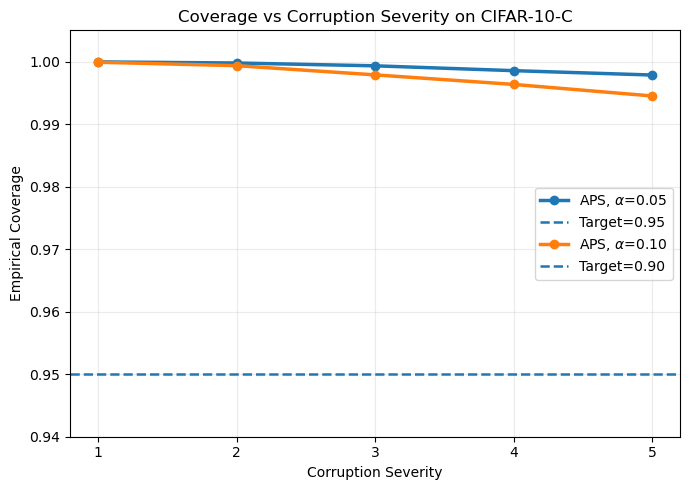

Saved: /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step2_coverage_clean.png


In [10]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
PROJECT_ROOT = os.getcwd()
OUTPUT_ROOT = os.path.join(PROJECT_ROOT, "shift_aware_conformal_outputs")
RESULTS_CSV = os.path.join(OUTPUT_ROOT, "step2_cifar10c_results.csv")
SAVE_PATH = os.path.join(OUTPUT_ROOT, "step2_coverage_clean.png")

# -----------------------------
# Load results
# -----------------------------
all_results = []
with open(RESULTS_CSV, "r", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        all_results.append({
            "severity": int(row["severity"]),
            "alpha": float(row["alpha"]),
            "empirical_coverage": float(row["empirical_coverage"]),
        })

alphas = sorted(set(r["alpha"] for r in all_results))
severities = sorted(set(r["severity"] for r in all_results))

# -----------------------------
# One clean plot
# -----------------------------
plt.figure(figsize=(7, 5))

for alpha in alphas:
    mean_cov = []
    for severity in severities:
        vals = [
            r["empirical_coverage"]
            for r in all_results
            if abs(r["alpha"] - alpha) < 1e-12 and r["severity"] == severity
        ]
        mean_cov.append(np.mean(vals))

    plt.plot(
        severities,
        mean_cov,
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=f"APS, $\\alpha$={alpha:.2f}"
    )

    plt.axhline(
        y=1 - alpha,
        linestyle="--",
        linewidth=1.8,
        label=f"Target={1-alpha:.2f}"
    )

plt.xlabel("Corruption Severity")
plt.ylabel("Empirical Coverage")
plt.title("Coverage vs Corruption Severity on CIFAR-10-C")
plt.xticks(severities)
plt.ylim(0.94, 1.005)   # adjust if needed
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", SAVE_PATH)

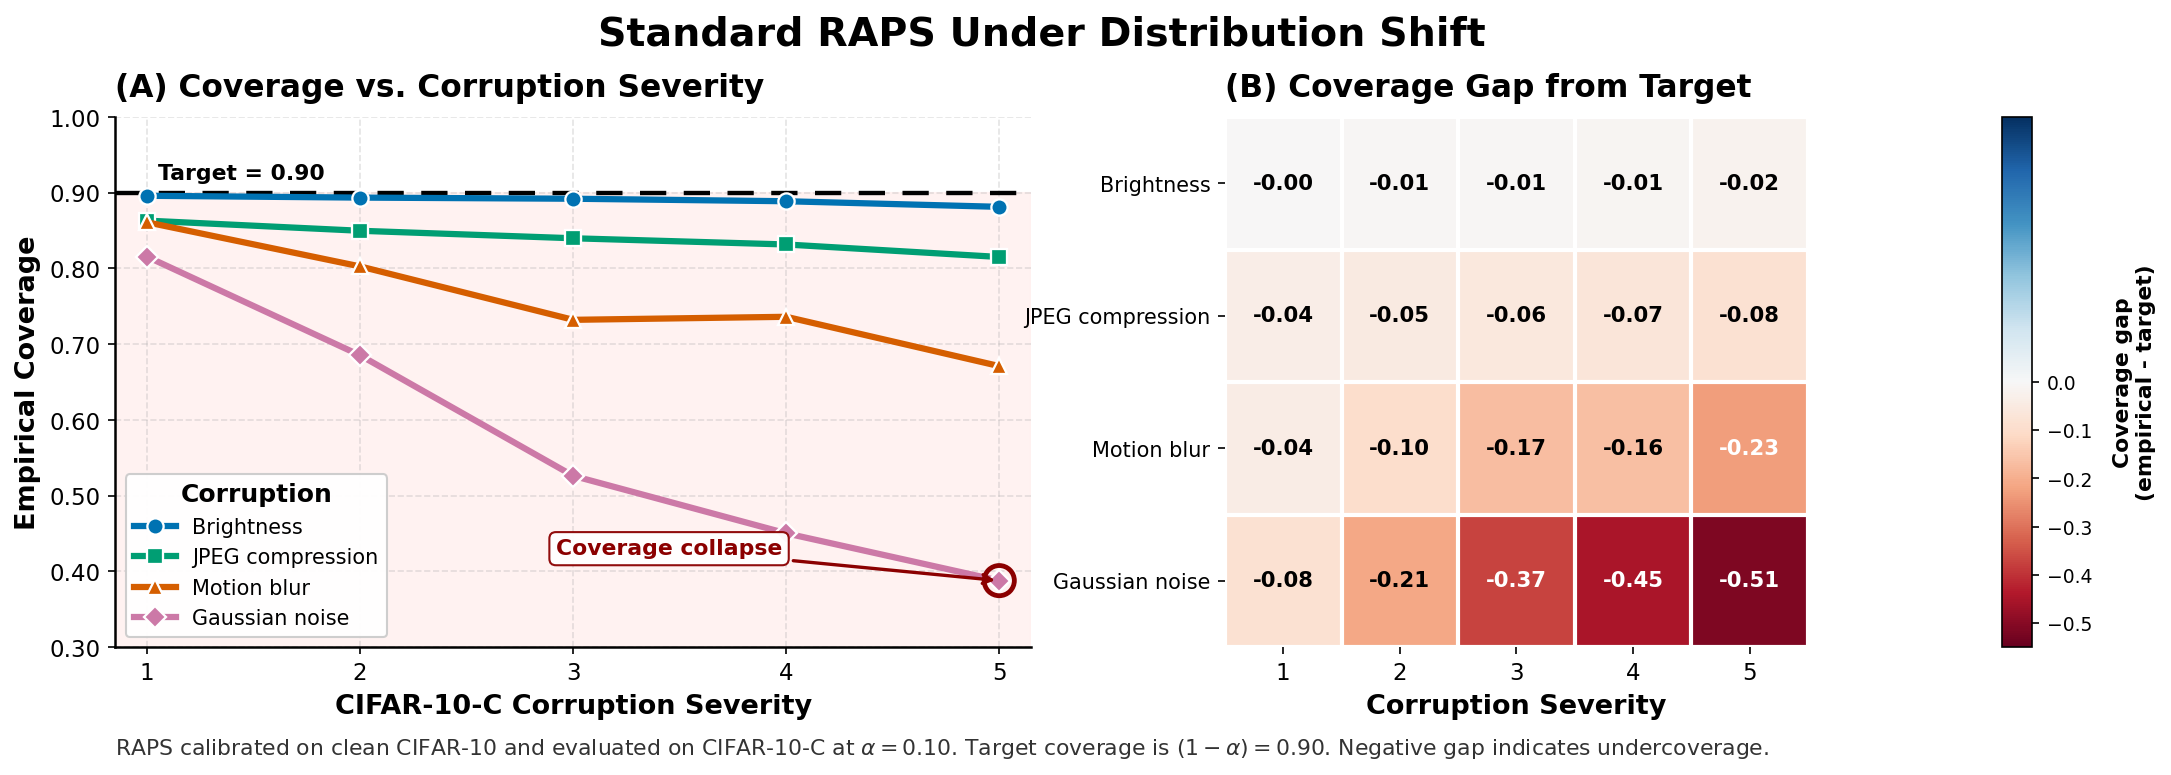

Saved PNG: shift_aware_conformal_outputs/final_poster_figures/advanced_no_overlap_standard_raps_coverage_and_gap_alpha_0p10.png
Saved PDF: shift_aware_conformal_outputs/final_poster_figures/advanced_no_overlap_standard_raps_coverage_and_gap_alpha_0p10.pdf
Saved SVG: shift_aware_conformal_outputs/final_poster_figures/advanced_no_overlap_standard_raps_coverage_and_gap_alpha_0p10.svg


In [7]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# Advanced no-overlap publishable figure:
# Standard RAPS Coverage Degrades Under Shift
# Panel A: Coverage curves
# Panel B: Coverage gap heatmap
# ============================================================

CSV_PATH = "shift_aware_conformal_outputs/step2_cifar10c_results_raps.csv"

FIG_DIR = Path("shift_aware_conformal_outputs/final_poster_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

ALPHA_VALUE = 0.10
TARGET_COVERAGE = 1.0 - ALPHA_VALUE

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
df = pd.read_csv(CSV_PATH)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

required_cols = ["corruption", "severity", "alpha", "empirical_coverage"]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing columns: {missing}. Available columns: {df.columns.tolist()}")

plot_df = df[np.isclose(df["alpha"], ALPHA_VALUE)].copy()

if "coverage_gap" not in plot_df.columns:
    plot_df["coverage_gap"] = plot_df["empirical_coverage"] - TARGET_COVERAGE

# ------------------------------------------------------------
# Names, order, colors
# ------------------------------------------------------------
name_map = {
    "brightness": "Brightness",
    "jpeg_compression": "JPEG compression",
    "motion_blur": "Motion blur",
    "gaussian_noise": "Gaussian noise",
}

plot_order = [
    "brightness",
    "jpeg_compression",
    "motion_blur",
    "gaussian_noise",
]

colors = {
    "brightness": "#0072B2",
    "jpeg_compression": "#009E73",
    "motion_blur": "#D55E00",
    "gaussian_noise": "#CC79A7",
}

markers = {
    "brightness": "o",
    "jpeg_compression": "s",
    "motion_blur": "^",
    "gaussian_noise": "D",
}

plot_df = plot_df[plot_df["corruption"].isin(plot_order)].copy()
plot_df["corruption"] = pd.Categorical(
    plot_df["corruption"],
    categories=plot_order,
    ordered=True
)
plot_df = plot_df.sort_values(["corruption", "severity"])

# ------------------------------------------------------------
# Publication style
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ------------------------------------------------------------
# Layout: 3 columns = line plot, heatmap, colorbar
# This prevents overlap.
# ------------------------------------------------------------
fig = plt.figure(figsize=(14.2, 5.7))

gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1.65, 1.05, 0.055],
    left=0.065,
    right=0.965,
    bottom=0.20,
    top=0.82,
    wspace=0.38
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

# ============================================================
# Panel A: Coverage curves
# ============================================================

ax1.axhspan(
    0.30,
    TARGET_COVERAGE,
    color="#FFF1F0",
    alpha=0.90,
    zorder=0
)

ax1.axhline(
    TARGET_COVERAGE,
    color="black",
    linestyle=(0, (6, 4)),
    linewidth=2.1,
    zorder=2
)

ax1.text(
    1.05,
    TARGET_COVERAGE + 0.012,
    f"Target = {TARGET_COVERAGE:.2f}",
    fontsize=10.5,
    color="black",
    weight="bold",
    ha="left",
    va="bottom"
)

for corruption in plot_order:
    sub = plot_df[plot_df["corruption"] == corruption].sort_values("severity")

    ax1.plot(
        sub["severity"],
        sub["empirical_coverage"],
        color=colors[corruption],
        marker=markers[corruption],
        linewidth=3.0,
        markersize=7.8,
        markeredgecolor="white",
        markeredgewidth=1.1,
        label=name_map[corruption],
        zorder=3
    )

# Highlight Gaussian noise severity 5
gauss = plot_df[plot_df["corruption"] == "gaussian_noise"].sort_values("severity")

if not gauss.empty:
    sev5 = gauss[gauss["severity"] == 5]

    if not sev5.empty:
        x5 = sev5["severity"].iloc[0]
        y5 = sev5["empirical_coverage"].iloc[0]

        ax1.scatter(
            [x5],
            [y5],
            s=210,
            facecolors="none",
            edgecolors="#8B0000",
            linewidths=2.3,
            zorder=5
        )

        ax1.annotate(
            "Coverage collapse",
            xy=(x5, y5),
            xytext=(3.45, 0.43),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.6,
                color="#8B0000"
            ),
            fontsize=10.5,
            color="#8B0000",
            weight="bold",
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.30",
                facecolor="white",
                edgecolor="#8B0000",
                alpha=0.95
            )
        )

ax1.set_title("(A) Coverage vs. Corruption Severity", loc="left", pad=10)
ax1.set_xlabel("CIFAR-10-C Corruption Severity")
ax1.set_ylabel("Empirical Coverage")

ax1.set_xlim(0.85, 5.15)
ax1.set_ylim(0.30, 1.00)
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

ax1.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_linewidth(1.2)
ax1.spines["bottom"].set_linewidth(1.2)

legend = ax1.legend(
    loc="lower left",
    frameon=True,
    framealpha=0.96,
    edgecolor="#CCCCCC",
    title="Corruption"
)
legend.get_title().set_fontweight("bold")

# ============================================================
# Panel B: Coverage gap heatmap
# ============================================================

heat_df = plot_df.pivot(
    index="corruption",
    columns="severity",
    values="coverage_gap"
).loc[plot_order]

heat_values = heat_df.values

norm = TwoSlopeNorm(
    vmin=min(-0.55, np.nanmin(heat_values)),
    vcenter=0.0,
    vmax=max(0.03, np.nanmax(heat_values))
)

im = ax2.imshow(
    heat_values,
    aspect="auto",
    cmap="RdBu",
    norm=norm
)

ax2.set_title("(B) Coverage Gap from Target", loc="left", pad=10)
ax2.set_xlabel("Corruption Severity")

# IMPORTANT: no y-axis label here, because it causes overlap
ax2.set_ylabel("")

ax2.set_xticks(np.arange(len(heat_df.columns)))
ax2.set_xticklabels([str(c) for c in heat_df.columns])

ax2.set_yticks(np.arange(len(heat_df.index)))
ax2.set_yticklabels([name_map[c] for c in heat_df.index], fontsize=10)

# Cell annotations
for i in range(heat_values.shape[0]):
    for j in range(heat_values.shape[1]):
        val = heat_values[i, j]
        text_color = "white" if val < -0.22 else "black"

        ax2.text(
            j,
            i,
            f"{val:+.2f}",
            ha="center",
            va="center",
            fontsize=10.2,
            weight="bold",
            color=text_color
        )

# Clean heatmap borders
for spine in ax2.spines.values():
    spine.set_visible(False)

ax2.set_xticks(np.arange(-0.5, len(heat_df.columns), 1), minor=True)
ax2.set_yticks(np.arange(-0.5, len(heat_df.index), 1), minor=True)
ax2.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax2.tick_params(which="minor", bottom=False, left=False)

# Dedicated colorbar axis = no overlap
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(
    "Coverage gap\n(empirical - target)",
    fontsize=10.5,
    weight="bold",
    labelpad=10
)
cbar.ax.tick_params(labelsize=9)

# ------------------------------------------------------------
# Main title and footer note
# ------------------------------------------------------------
fig.suptitle(
    "Standard RAPS Under Distribution Shift",
    fontsize=19,
    fontweight="bold",
    y=0.94
)

fig.text(
    0.065,
    0.075,
    r"RAPS calibrated on clean CIFAR-10 and evaluated on CIFAR-10-C at $\alpha=0.10$. "
    r"Target coverage is $(1-\alpha)=0.90$. Negative gap indicates undercoverage.",
    fontsize=10.5,
    color="#333333"
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
base_name = "advanced_no_overlap_standard_raps_coverage_and_gap_alpha_0p10"

png_path = FIG_DIR / f"{base_name}.png"
pdf_path = FIG_DIR / f"{base_name}.pdf"
svg_path = FIG_DIR / f"{base_name}.svg"

plt.savefig(png_path, bbox_inches="tight", dpi=600)
plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(svg_path, bbox_inches="tight")

plt.show()

print("Saved PNG:", png_path)
print("Saved PDF:", pdf_path)
print("Saved SVG:", svg_path)

Available columns: ['method', 'lambda_reg', 'k_reg', 'randomized', 'corruption', 'severity', 'alpha', 'target_coverage', 'qhat', 'empirical_coverage', 'coverage_gap', 'avg_set_size']
Available alpha values: [np.float64(0.05), np.float64(0.1)]


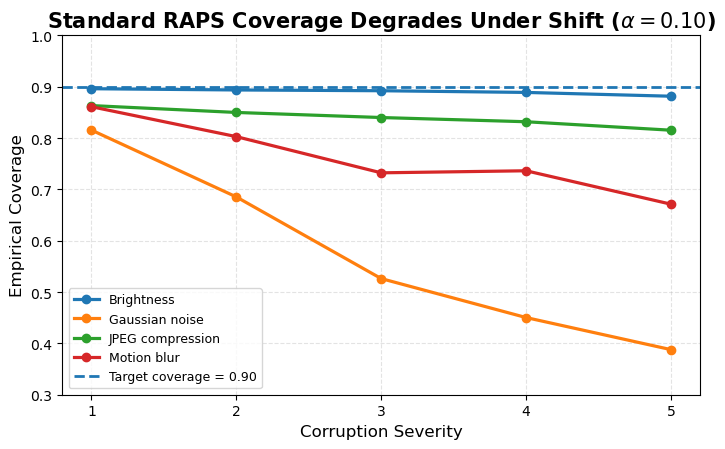

Saved PNG: shift_aware_conformal_outputs/final_poster_figures/standard_raps_coverage_degrades_under_shift_alpha_0p1.png
Saved PDF: shift_aware_conformal_outputs/final_poster_figures/standard_raps_coverage_degrades_under_shift_alpha_0p1.pdf


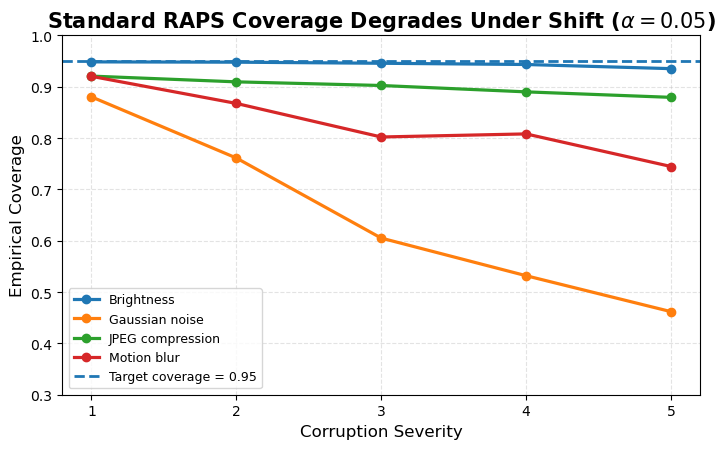

Saved PNG: shift_aware_conformal_outputs/final_poster_figures/standard_raps_coverage_degrades_under_shift_alpha_0p05.png
Saved PDF: shift_aware_conformal_outputs/final_poster_figures/standard_raps_coverage_degrades_under_shift_alpha_0p05.pdf


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Standard RAPS Coverage Under Shift for Different Alpha Values
# ============================================================

CSV_PATH = "shift_aware_conformal_outputs/step2_cifar10c_results_raps.csv"

FIG_DIR = "shift_aware_conformal_outputs/final_poster_figures"
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("Available columns:", df.columns.tolist())
print("Available alpha values:", sorted(df["alpha"].unique()))

# Optional: keep only RAPS rows if method column exists
if "method" in df.columns:
    df = df[df["method"].str.lower().str.contains("raps")].copy()

# Nice display names
name_map = {
    "gaussian_noise": "Gaussian noise",
    "motion_blur": "Motion blur",
    "brightness": "Brightness",
    "jpeg_compression": "JPEG compression",
}

# Choose alpha values to plot
alpha_values = [0.10, 0.05]

for alpha in alpha_values:
    sub_alpha = df[np.isclose(df["alpha"], alpha)].copy()
    
    if sub_alpha.empty:
        print(f"No results found for alpha={alpha}")
        continue
    
    sub_alpha = sub_alpha.sort_values(["corruption", "severity"])
    
    target_coverage = 1.0 - alpha
    
    plt.figure(figsize=(7.2, 4.6))
    
    for corruption in sub_alpha["corruption"].unique():
        sub = sub_alpha[sub_alpha["corruption"] == corruption]
        
        label = name_map.get(
            str(corruption),
            str(corruption).replace("_", " ").title()
        )
        
        plt.plot(
            sub["severity"],
            sub["empirical_coverage"],
            marker="o",
            linewidth=2.3,
            markersize=6,
            label=label
        )
    
    plt.axhline(
        y=target_coverage,
        linestyle="--",
        linewidth=2,
        label=f"Target coverage = {target_coverage:.2f}"
    )
    
    plt.title(
        f"Standard RAPS Coverage Degrades Under Shift ($\\alpha={alpha:.2f}$)",
        fontsize=15,
        fontweight="bold"
    )
    plt.xlabel("Corruption Severity", fontsize=12)
    plt.ylabel("Empirical Coverage", fontsize=12)
    
    plt.xticks([1, 2, 3, 4, 5])
    plt.ylim(0.30, 1.00)
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend(frameon=True, fontsize=9)
    plt.tight_layout()
    
    alpha_name = str(alpha).replace(".", "p")
    
    png_path = os.path.join(
        FIG_DIR,
        f"standard_raps_coverage_degrades_under_shift_alpha_{alpha_name}.png"
    )
    pdf_path = os.path.join(
        FIG_DIR,
        f"standard_raps_coverage_degrades_under_shift_alpha_{alpha_name}.pdf"
    )
    
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    
    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")